# Polarization Notebook


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Import Libraries</h2>
</div>

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
import serial
import time
import pyvisa

from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path

from datetime import datetime
import json

c:\Users\hlab_\anaconda3\envs\qickdawg_jeree\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Connect to Laser and Board</h2>
</div>

In [2]:
qd.start_client('10.225.208.77')
ser_laser = serial.Serial(
    port='COM3',
    baudrate=9600,
    stopbits=1,
    bytesize=8,
    parity='N',
    xonxoff=True)

ser_laser.write(b'*ON\r')
ser_laser.write(b'EXT\r')  
#ser_laser.write(b'LAS\r')

4

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Assigning Default Configurations</h2>
</div>
<a class="anchor" id="first-bullet"></a>

These are standard settings used across most, if not all, qickdawg programs <br>
Commonly used attributes:
- adc_channel: 0 or 1 and should be DC coupled through a differential amplifier (adc_channel = 0 if following Readme)
- mw_channel: microwave exciation channel, can be 0 or 1 for RFSoC4x2 or 0 to 6 for ZCU111 & ZCU216
- mw_nqz: Nyquist zone for the microwave generator. 1 for f < fdss/2 and 2 for f> fdss/2 
- mw_gain: Effectively mw amplitude.  From 0 to 2e15-1, i.e. 32767
- laser_gate_pmod: PMOD channel used to gate the laser on/off
- relax_delay_t#: delay time at the end of a pulse sequence, typically 500ns is sufficient


In [3]:
default_config = qd.NVConfiguration()

default_config.adc_channel = 0
default_config.edge_counting = True

# Hysteresis thresholds prevent double-counting from noise: signal must rise above high_threshold to register a photon, then fall below low_threshold before it can register the next one
default_config.high_threshold = 8000
default_config.low_threshold = 500

default_config.mw_channel = 1
default_config.mw_nqz = 1
default_config.mw_gain = 5000

default_config.laser_gate_pmod = 0
default_config.adc_trigger_pmod = 1

default_config.relax_delay_tns = 2000  # between each rep, wait for everything to catch up

# --- GateSweep-specific ---
default_config.laser_on_tus = 8.0        # polarization pulse duration, literature-backed for V_B-

default_config.readout_integration_tns = 20    # START HERE, narrow gate. Shrink (10, 5, ...) once
                                          # you find where the hardware complains or stops changing.

default_config.delay_start_tns = -100    # sweep window straddling the laser turn-ON edge --
default_config.delay_end_tns = 300       # this is the edge the 50 ns AOM buffer normally protects

default_config.nsweep_points = 200
default_config.reps = 5000               # narrow gate -> few counts/rep -> average a lot

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Laser Functions</h2>
</div>

In [4]:
def On():
    qd.laser_on(default_config)
    
def Off():
    SetPower(0)

def SetPower(power):
    command = f'PWR{power}\r'.encode()
    ser_laser.write(command)

In [6]:
On()
SetPower(10)

In [7]:
SetPower(20)

In [ ]:

try:
    print("Toggling laser... press the Jupyter stop button (■) or Ctrl+C to stop.")
    while True:
        qd.laser_on(default_config)
        time.sleep(0.05)
        qd.laser_off(default_config)
        time.sleep(0.05)
except KeyboardInterrupt:
    qd.laser_off(default_config)
    print("Stopped, laser off.")

Toggling laser... press the Jupyter stop button (■) or Ctrl+C to stop.
Stopped, laser off.


: 

In [10]:
t0 = time.time()
qd.laser_on(default_config)
t1 = time.time()
qd.laser_off(default_config)
t2 = time.time()

print(f"laser_on took {t1-t0:.3f}s, laser_off took {t2-t1:.3f}s")

laser_on took 0.571s, laser_off took 0.836s


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Setup Saving</h2>
</div>

In [6]:
# Parent directory where all measurement data is saved
parent_save_dir = Path(r"C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data")

# Create it if it doesn't already exist (safe to run even if it does)
parent_save_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving to: {parent_save_dir}")
print(f"Exists: {parent_save_dir.exists()}")

Saving to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data
Exists: True


<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Save Functions</h3>
</div>

In [7]:
def create_experiment_folder(subfolder_name, parent_dir=parent_save_dir):
    """
    Creates a new timestamped, numbered experiment folder inside
    parent_dir/subfolder_name, and returns the Path to it.
    """
    subfolder_path = parent_dir / subfolder_name
    subfolder_path.mkdir(parents=True, exist_ok=True)

    # Count existing experiment folders to figure out the next experiment number
    existing_experiments = [p for p in subfolder_path.iterdir() if p.is_dir()]
    experiment_number = len(existing_experiments) + 1

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    experiment_folder = subfolder_path / f"{timestamp}_{experiment_number:03d}"
    experiment_folder.mkdir(parents=True, exist_ok=False)

    return experiment_folder

def save_metadata(run_folder, params: dict, filename="metadata.json"):
    with open(run_folder / filename, "w") as f:
        json.dump(params, f, indent=4)

def run_and_save_gate_sweep(config, edge_label, laser_power):
    """
    Runs a GateSweep measurement, then saves the plot (with params annotated
    on it), the raw data, and the full metadata -- all into one timestamped
    folder under Polarization_Msmnts.
    """
    program = qd.GateSweep(config)
    data = program.acquire(progress=True)

    # average over the reps axis, then drop the leftover size-1 axis
    data_mean = data.mean(axis=0).squeeze()

    delays_ns = (program.qick_sweeps[0].get_sweep_pts() * program.cycles2us(1) * 1000
                 - config.pre_offset_tns)

    # --- Create the experiment folder ---
    run_folder = create_experiment_folder("Polarization_Msmnts")

    # --- Build metadata ---
    metadata = {
        "edge": edge_label,
        "laser_power_percent": laser_power,
        "laser_on_tus": config.laser_on_tus,
        "gate_width_tns": config.readout_integration_tns,
        "pre_offset_tns": config.pre_offset_tns,
        "delay_start_tns": config.delay_start_tns,
        "delay_end_tns": config.delay_end_tns,
        "nsweep_points": config.nsweep_points,
        "reps": config.reps,
        "relax_delay_tns": config.relax_delay_tns,
        "high_threshold": config.high_threshold,
        "low_threshold": config.low_threshold,
        "timestamp": datetime.now().isoformat(),
    }
    save_metadata(run_folder, metadata)

    # --- Save raw data (both raw per-rep and averaged) ---
    np.savez(run_folder / "data.npz", delays_ns=delays_ns, counts_mean=data_mean, counts_raw=data)

    # --- Plot, with key params annotated directly on it ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(delays_ns, data_mean, 'o-')
    ax.set_xlabel('delay relative to laser turn-on (ns)')
    ax.set_ylabel('mean counts per rep')
    ax.set_title(f'GateSweep -- {edge_label} edge')

    param_text = (
        f"folder = {run_folder.name}\n"
        f"laser_on = {metadata['laser_on_tus']} us\n"
        f"gate width = {metadata['gate_width_tns']} ns\n"
        f"power = {metadata['laser_power_percent']}%\n"
        f"reps = {metadata['reps']}\n"
        f"sweep = {metadata['delay_start_tns']} to {metadata['delay_end_tns']} ns "
        f"(shifted by pre_offset={metadata['pre_offset_tns']} ns), {metadata['nsweep_points']} pts"
    )
    
    ax.text(0.02, 0.98, param_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    fig.savefig(run_folder / "plot.png", dpi=150)
    plt.show()

    print(f"Saved to: {run_folder}")

    return delays_ns, data_mean, run_folder

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Run</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Check Counts</h3>
</div>

In [16]:
SetPower(0)

In [174]:
# Configuring settings 
config = copy(default_config)
config.readout_integration_treg = 2**16 - 1  # max integrated points
config.reps = 1

prog = qd.PLIntensity(config)
counts = prog.acquire()

cps = counts / config.readout_integration_treg / qd.min_time_tns * 1e9
mcps = cps / 1e6

print('{} photons counted'.format(counts))
print('{} cps'.format(cps))
print('{} Mcps'.format(mcps))

4 photons counted
18750.286106660562 cps
0.01875028610666056 Mcps


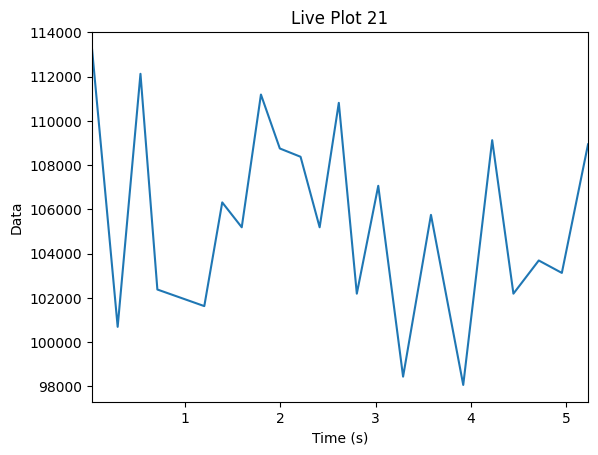

In [15]:
config = copy(default_config)
config.readout_integration_treg = 2**14
config.reps = 100

prog = qd.PLIntensity(config)

def get_cps():
    d = prog.acquire(progress=False)
    total_treg = config.readout_integration_treg * config.reps
    return d / total_treg / qd.min_time_tns * 1e9 
# normalize counts by total integration time (window × reps) to get counts/sec, 
# so live_plot shows a real-time photon count rate

#y-axis is counts per second (cps)

qd.live_plot(get_cps)

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Check Detector Linearity</h3>
</div>

power=0%  cps=75 ± 92  efficiency=nan
power=10%  cps=18450 ± 971  efficiency=1845.0
power=20%  cps=29381 ± 2138  efficiency=1469.1
power=30%  cps=39281 ± 2177  efficiency=1309.4
power=40%  cps=52012 ± 2459  efficiency=1300.3
power=50%  cps=61144 ± 5212  efficiency=1222.9
power=60%  cps=71981 ± 4414  efficiency=1199.7
power=70%  cps=84769 ± 3748  efficiency=1211.0
power=80%  cps=95662 ± 3332  efficiency=1195.8
power=90%  cps=103781 ± 4811  efficiency=1153.1
power=100%  cps=112106 ± 2939  efficiency=1121.1
Done. Laser power set to 0%.


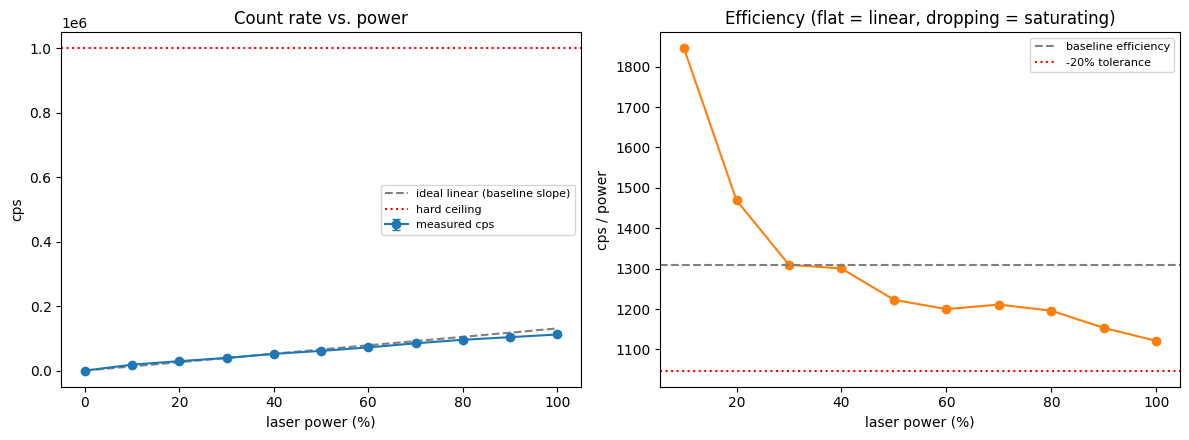

In [188]:
HARD_CEILING_CPS = 1_000_000
EFFICIENCY_DROP_TOLERANCE = 0.20
N_AVERAGES = 10
SETTLE_TIME_S = 2.0   # seconds to wait after changing power before trusting readings -- adjust up if still noisy
BASELINE_POWER = 30

def averaged_cps(n=N_AVERAGES):
    readings = [get_cps() for _ in range(n)]
    return np.mean(readings), np.std(readings)

power_steps = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

baseline_efficiency = None
results = []
aborted_at = None

for power in power_steps:
    SetPower(power)
    time.sleep(SETTLE_TIME_S)   # let the laser settle before measuring
    cps_mean, cps_std = averaged_cps()
    efficiency = cps_mean / power if power > 0 else float('nan')

    if power == BASELINE_POWER:
        baseline_efficiency = efficiency
    
    results.append((power, cps_mean, cps_std, efficiency))
    print(f"power={power}%  cps={cps_mean:.0f} ± {cps_std:.0f}  efficiency={efficiency:.1f}")

    if cps_mean > HARD_CEILING_CPS:
        print(f"ABORT: hard ceiling ({HARD_CEILING_CPS} cps) exceeded at {power}% power.")
        aborted_at = power
        break

    if baseline_efficiency is not None and efficiency < baseline_efficiency * (1 - EFFICIENCY_DROP_TOLERANCE):
        print(f"ABORT: efficiency dropped >{EFFICIENCY_DROP_TOLERANCE*100:.0f}% from baseline at {power}% power "
              f"-- likely approaching saturation.")
        aborted_at = power
        break

SetPower(0)
print("Done. Laser power set to 0%.")

powers, cps_means, cps_stds, efficiencies = zip(*results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.errorbar(powers, cps_means, yerr=cps_stds, fmt='o-', capsize=3, label='measured cps')
ideal_line = np.array(powers) * baseline_efficiency
ax1.plot(powers, ideal_line, '--', color='gray', label='ideal linear (baseline slope)')
ax1.axhline(HARD_CEILING_CPS, color='red', linestyle=':', label='hard ceiling')
ax1.set_xlabel('laser power (%)')
ax1.set_ylabel('cps')
ax1.set_title('Count rate vs. power')
ax1.legend(fontsize=8)

nonzero_mask = np.array(powers) > 0
ax2.plot(np.array(powers)[nonzero_mask], np.array(efficiencies)[nonzero_mask], 'o-', color='tab:orange')
ax2.axhline(baseline_efficiency, color='gray', linestyle='--', label='baseline efficiency')
ax2.axhline(baseline_efficiency * (1 - EFFICIENCY_DROP_TOLERANCE), color='red', linestyle=':',
            label=f'-{EFFICIENCY_DROP_TOLERANCE*100:.0f}% tolerance')
ax2.set_xlabel('laser power (%)')
ax2.set_ylabel('cps / power')
ax2.set_title('Efficiency (flat = linear, dropping = saturating)')
ax2.legend(fontsize=8)

if aborted_at is not None:
    fig.suptitle(f'Aborted at {aborted_at}% power', color='red')

plt.tight_layout()
plt.show()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Run</h3>
</div>

In [8]:
SetPower(100)

100%|██████████| 1000000/1000000 [00:02<00:00, 490106.50it/s]


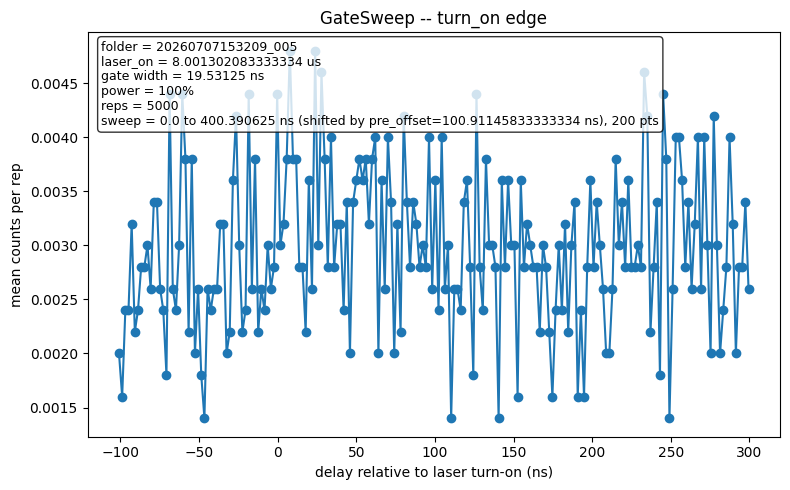

Saved to: C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Polarization_Msmnts\20260707153209_005


In [38]:
config = copy(default_config)

config.laser_on_tus = 8.0
config.readout_integration_tns = 20
config.relax_delay_tns = 2000 
config.pre_offset_tns = 100
config.delay_start_tns = 0
config.delay_end_tns = 400
config.nsweep_points = 200
config.reps = 5000   

delays_ns, data_mean, run_folder = run_and_save_gate_sweep(config, edge_label="turn_on", laser_power=100)


Off()

100%|██████████| 2500/2500 [00:00<00:00, 213790.04it/s]


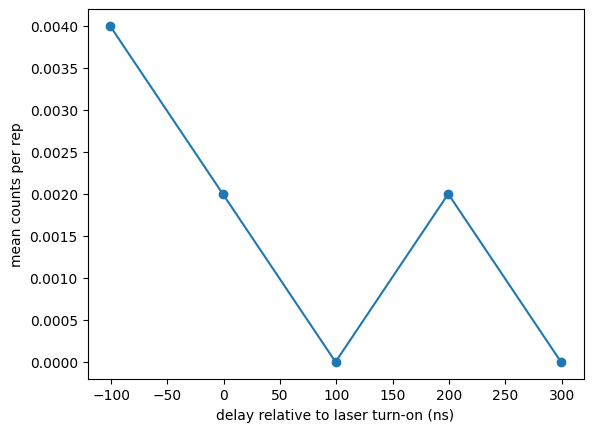

In [10]:
config = copy(default_config)
config.laser_on_tus = 8.0
config.readout_integration_tns = 20
config.pre_offset_tns = 100
config.delay_start_tns = 0
config.delay_end_tns = 400
config.nsweep_points = 5
config.reps = 500

test_program = qd.GateSweep(config)
data = test_program.acquire(progress=True)
data_mean = data.mean(axis=0).squeeze()

delays_ns = test_program.qick_sweeps[0].get_sweep_pts() * test_program.cycles2us(1) * 1000 - config.pre_offset_tns
plt.plot(delays_ns, data_mean, 'o-')
plt.xlabel('delay relative to laser turn-on (ns)')
plt.ylabel('mean counts per rep')
plt.show()